In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/syedaeman2212/airline-ticket-prices-dataset/airline_ticket_prices_dataset.csv


In [2]:
#importing libraries
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split


2026-03-09 08:50:32.069251: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773046232.413721      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773046232.504205      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773046233.315525      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773046233.315593      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773046233.315596      17 computation_placer.cc:177] computation placer alr

In [3]:
#reading data
df=pd.read_csv(os.path.join(dirname, filename))

In [4]:
df.head()

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
0,1,Saudia,Mumbai,Paris,2643,Economy,28,555.30
1,2,Etihad,Istanbul,Jeddah,8266,Business,98,2070.27
2,3,British Airways,Dubai,Riyadh,2698,First,21,1883.11
3,4,Emirates,London,Istanbul,7956,First,24,5349.65
4,5,Qatar Airways,Doha,Dubai,1308,Business,60,516.19


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              250 non-null    int64  
 1   Airline                250 non-null    object 
 2   Origin                 250 non-null    object 
 3   Destination            250 non-null    object 
 4   Distance_km            250 non-null    int64  
 5   Class                  250 non-null    object 
 6   Days_Before_Departure  250 non-null    int64  
 7   Price_USD              250 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 15.8+ KB


In [6]:
df.isnull().sum()

Ticket_ID                0
Airline                  0
Origin                   0
Destination              0
Distance_km              0
Class                    0
Days_Before_Departure    0
Price_USD                0
dtype: int64

In [7]:
for i in df.columns:
    print(df[i].value_counts())
    print('-------------------------------------')

Ticket_ID
1      1
2      1
3      1
4      1
5      1
      ..
246    1
247    1
248    1
249    1
250    1
Name: count, Length: 250, dtype: int64
-------------------------------------
Airline
British Airways     36
Qatar Airways       36
Lufthansa           34
Saudia              32
Emirates            32
Turkish Airlines    30
Flynas              26
Etihad              24
Name: count, dtype: int64
-------------------------------------
Origin
Paris       32
Istanbul    31
Doha        28
London      27
Mumbai      26
Riyadh      23
Jeddah      22
New York    21
Cairo       21
Dubai       19
Name: count, dtype: int64
-------------------------------------
Destination
Cairo       36
Riyadh      32
Istanbul    30
Paris       29
New York    24
Dubai       24
London      20
Doha        19
Mumbai      19
Jeddah      17
Name: count, dtype: int64
-------------------------------------
Distance_km
6188     2
8266     1
2698     1
7956     1
1308     1
        ..
2389     1
6941     1
7396     1


In [8]:
df=df.drop('Ticket_ID',axis=1)

In [9]:
df=pd.get_dummies(df,drop_first=True)

In [10]:
x=df.drop("Price_USD",axis=1)

In [11]:
y=df['Price_USD']

In [12]:
x.shape,y.shape

((250, 29), (250,))

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)

In [14]:
ss=StandardScaler()


In [15]:
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [16]:
model=Sequential()

In [17]:
model.add(Dense(64,activation='relu',input_shape=(x_train.shape[1],)))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-09 08:51:00.186934: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
model.compile(optimizer='adam',loss='huber',metrics=['mae'])

In [19]:
model.fit(x_train,y_train,epochs =40,batch_size=1,validation_split=0.1)

Epoch 1/40
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2131.7026 - mae: 2132.2026 - val_loss: 1481.8406 - val_mae: 1482.3406
Epoch 2/40
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1707.6986 - mae: 1708.1986 - val_loss: 873.5315 - val_mae: 874.0315
Epoch 3/40
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 904.2183 - mae: 904.7183 - val_loss: 742.4346 - val_mae: 742.9346
Epoch 4/40
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 531.0044 - mae: 531.5044 - val_loss: 640.7351 - val_mae: 641.2351
Epoch 5/40
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 440.3196 - mae: 440.8159 - val_loss: 577.2215 - val_mae: 577.7205
Epoch 6/40
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 427.7741 - mae: 428.2741 - val_loss: 550.1735 - val_mae: 550.6735
Epoch 7/40
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 333.8600 - mae: 334.3594 - val_loss: 509.3280 - val_mae: 509.8280
Epoch 8/40
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 289.6384 - mae: 290.1379 - val_loss: 475.8530 - val_

In [20]:
y_pred=model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


In [21]:
r2=r2_score(y_test,y_pred)

In [22]:
r2

0.8929806127777002

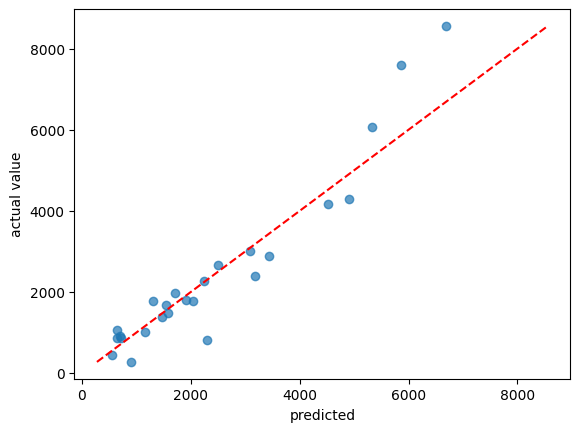

In [23]:
#plotting on graph
plt.scatter(y_pred,y_test,alpha=0.7)
plt.xlabel("predicted")
plt.ylabel("actual value")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')   